# Linear Models

In [22]:
	# load sample dataset
from pycaret.datasets import get_data
data = get_data('diabetes')

,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years),Class variable
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Learning Objectives

In this notebook we learn to:

Part 1:

1. Given a DataFrame, split the feature columns from the target columns
2. Train a regressor (`LinearRegression`) model
3. Inspect the learned parameters of the model
4. Predict the target for any feature value
5. Plot the data scatter plot
6. Plot the linear regression line on the same plot
7. Estimate the model error

Part 2:

1. Given a (features-target) split, further split the data into (train-test)
2. Justify having a held-out set for testing
3. Explain what the `stratify=target` parameter does
4. Train a classifier (`LogisticRegression`) model
5. Given a `DecisionBoundaryDisplay` distinguish between a classifier's `predict` and `predict_proba` methods

In [23]:
import pandas as pd
from sklearn.datasets import fetch_openml

# Load the penguins dataset from OpenML
penguins_openml = fetch_openml(name="penguins", version=1, as_frame=True)
penguins = penguins_openml.frame

In [24]:
penguins.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


## Part 1: Regression

In regression, the target to be predicted is a continuous variable.

For simplicity we will pick:

- one feature $x$: `flipper_length_mm`
- to predict the target $y$: `body_mass_g`

In [25]:
feature_name = "flipper_length_mm"
target_name = "body_mass_g"

data = penguins[[feature_name]]
target = penguins[target_name]

In [26]:
data.shape, target.shape

((344, 1), (344,))

Since the LinearRegression model fitting assumes no missing values, we shall fill them with their means. In a later section, we talk about this issue in more details:

In [27]:
data['flipper_length_mm'] = data['flipper_length_mm'].fillna(data['flipper_length_mm'].mean())
target = target.fillna(target.mean())

In [28]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(data, target)

LinearRegression()

The instance `linear_regression` stores the parameter values in the attributes `coef_` and `intercept_`. We can check what the optimal model found is:

In [29]:
model.coef_[0].round(2), model.intercept_.round(2)

(49.69, -5780.83)

In [30]:
model.predict([[200]])

array([4156.28192314])

For any new $x$ (feature value; `flipper_length_mm`), the model can predict a $\hat{y}$ for it:

In [31]:
model.predict([[200]])

array([4156.28192314])

Let's do this prediction for a range of values, to make a plot:

In [32]:
import numpy as np

flipper_length_range = np.linspace(data.min(), data.max(), num=300)
flipper_length_range[:3], flipper_length_range[-3:]

(array([[172.        ],
        [172.19732441],
        [172.39464883]]),
 array([[230.60535117],
        [230.80267559],
        [231.        ]]))

We can use the weight and intercept to plot the model found using the scikit-learn.



In [33]:
predicted_body_mass = model.predict(flipper_length_range)
predicted_body_mass[:5]

array([2765.08606377, 2774.89023908, 2784.69441439, 2794.4985897 ,
       2804.30276502])

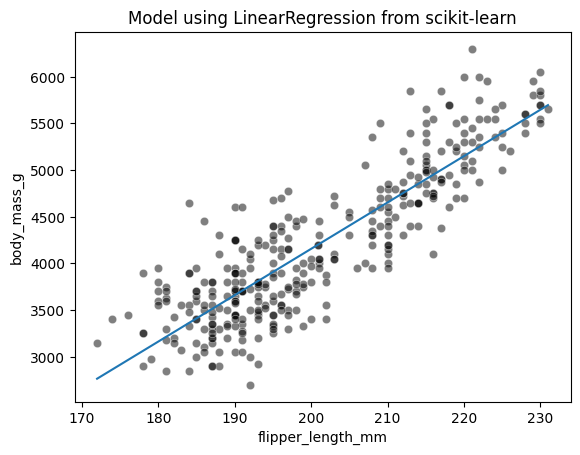

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(
    x=data[feature_name],
    y=target,
    color="black",
    alpha=0.5
)
plt.plot(
    flipper_length_range,
    predicted_body_mass,
)
_ = plt.title("Model using LinearRegression from scikit-learn")
plt.gcf().savefig("../assets/lab_linear_regression_line.png", bbox_inches="tight", dpi=150)

Let's measure the distances between the line and the points:

In [35]:
inferred_body_mass = model.predict(data)
inferred_body_mass - target

0     -537.743839
1     -339.316007
2      657.854091
3        0.000000
4      358.482958
          ...    
339      0.000000
340     51.565419
341   -500.635616
342   -447.491280
343   -597.805714
Name: body_mass_g, Length: 344, dtype: float64

The error, is the avergae distance; also known as the **mean absolute error**:

In [36]:
from sklearn.metrics import mean_absolute_error

model_error = mean_absolute_error(target, inferred_body_mass)
print(f"The mean absolute error of the optimal model is {model_error:.2f} g")

The mean absolute error of the optimal model is 311.18 g


A mean absolute error of 311 means that on average, our model make an error of ± 311 grams when predicting the body mass of a penguin given its flipper length.

## Part 2: Classification

In regression, we saw that the target to be predicted is a continuous variable. In classification, the target is discrete (e.g. categorical).

this time the task is to predict the penguin species using the culmen information. We also simplify our classification problem by selecting only 2 of the penguin species to solve a binary classification problem.

In [52]:
from sklearn.datasets import fetch_openml

# Load the penguins dataset from OpenML
penguins_openml = fetch_openml(name="penguins", version=1, as_frame=True)
penguins = penguins_openml.frame

Notice that we have three species. This makes it a multi-class classification problem. To make this a binary classification problem (for illustration purposes), we will only look at two species of penguins: `"Adelie"` and `"Chinstrap"`:

In [38]:
penguins = (
    penguins.set_index("species").loc[["Adelie", "Chinstrap"]].reset_index()
)
penguins['species'] = penguins['species'].cat.remove_unused_categories()

Notice we are going to use two features this time:

- $x_1$: `culmen_length_mm`
- $x_2$: `culmen_depth_mm`

In [39]:
feature_names = ["culmen_length_mm", "culmen_depth_mm"]
target_name = "species"
data, target = penguins[feature_names], penguins[target_name]

Again we'll fill the values with their mean for now:

In [40]:
for feat in feature_names:
    data[feat] = data[feat].fillna(data[feat].mean())
target = target.fillna(target.mode()[0])

**Why use a train/test split?** So far we have used the same data to fit the model and to evaluate it. That gives an overly optimistic view of performance: the model has already "seen" the answers during training. To get an honest estimate of how well the model will do on **new, unseen data**, we set aside part of the data as a **test set**. We fit the model only on the **training set** and evaluate it on the **test set**.

That way, the test set acts as a stand-in for future data we don't have yet.

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data, target,
    test_size=0.20,
    random_state=42,
    stratify=target
)

The `random_state` is known as a **seed** for the pseudo-randomness. Which would trigger the default `shuffle=True` parameter, mixing the data points so that their original order doesn't play a role in learning (since that's irrelevant).

In **small datasets** or **imbalanced datasets** (where one class significantly outweighs another), a purely random split might result in a training set that is missing a minority class entirely, or a test set that over-represents a specific class. The purpose of  `stratify=target` is to ensure that the class distribution (the proportion of each label; `"Adelie"` and `"Chinstrap"`) in the resulting subsets matches the distribution of the original dataset.

Here we specify the `test_size` to be 25% which leaves the rest 75% for the training data.

Let's inspect the resulting sets to see that in action:

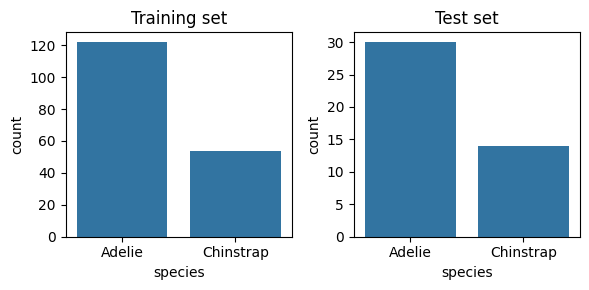

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(6, 3))

sns.countplot(x=y_train, ax=ax[0], color=sns.color_palette()[0])
sns.countplot(x=y_test, ax=ax[1], color=sns.color_palette()[0])
ax[0].set_title("Training set")
ax[1].set_title("Test set")
plt.tight_layout()
plt.gcf().savefig("../assets/lab_train_test_split_countplot.png", bbox_inches="tight", dpi=150)
plt.show()

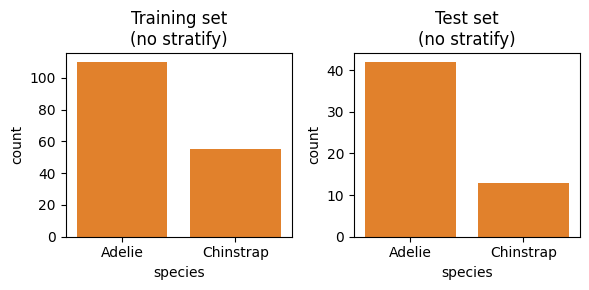

In [43]:
# Let's demonstrate what could happen if we split *without* using `stratify=target`.
# We'll use the same random_state to isolate the effect.

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    data, target,
    test_size=0.25,
    random_state=43,
    shuffle=True,
    stratify=None  # <--- NO stratification!
)

fig, ax = plt.subplots(1, 2, figsize=(6, 3))
sns.countplot(x=y_train2, ax=ax[0], color=sns.color_palette()[1])
sns.countplot(x=y_test2, ax=ax[1], color=sns.color_palette()[1])
ax[0].set_title("Training set\n(no stratify)")
ax[1].set_title("Test set\n(no stratify)")
plt.tight_layout()
plt.gcf().savefig("../assets/lab_train_test_split_no_stratify.png", bbox_inches="tight", dpi=150)
plt.show()

Of course we don't want that; so we will always using `stratify=y` when we split our data, especially when we have imbalance (gap in proprtions).

We can quickly start by visualizing the feature distribution by class:



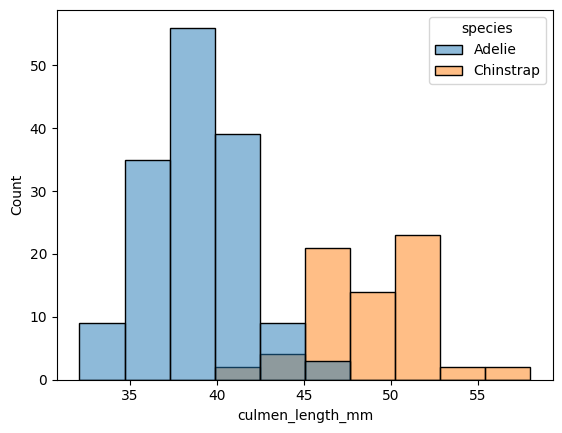

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(
    data=penguins,
    x="culmen_length_mm",
    hue=target_name
);
plt.gcf().savefig("../assets/lab_hist_culmen_length_mm.png", bbox_inches="tight", dpi=150)

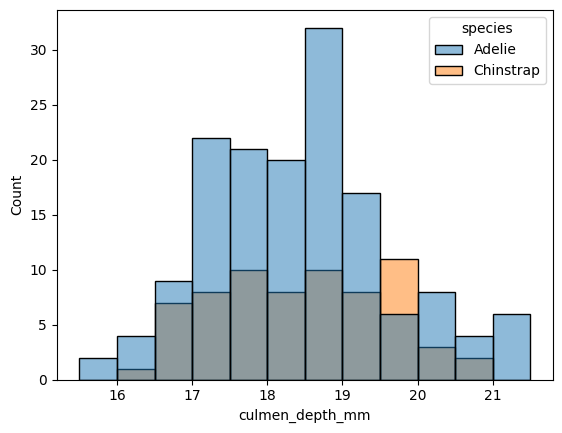

In [45]:
import matplotlib.pyplot as plt
sns.histplot(
    data=penguins,
    x="culmen_depth_mm",
    hue=target_name
);
plt.gcf().savefig("../assets/lab_hist_culmen_depth_mm.png", bbox_inches="tight", dpi=150)

We can observe that we have quite a simple problem.

- When the **culmen length** increases, the probability that the penguin is a Chinstrap is closer to 1.
- However, the **culmen depth** is not helpful for predicting the penguin species.

To fit a classification target, we use the `LogisticRegression` model to fit our data:

In [46]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

Likewise, the model can make predictions. For classification, `predict` returns the predicted class label:

In [47]:
import pandas as pd

predicted_species = model.predict(X_test)
predicted_proba = model.predict_proba(X_test)
# Show first few predictions alongside true labels (on the test set)
comparison = pd.DataFrame({
    feature_names[0]: X_test[feature_names[0]].values,
    "true": y_test.values,
    "predicted": predicted_species,
    "predicted_adelie": predicted_proba[:, 0],
    "predicted_chinstrap": predicted_proba[:, 1]
})
comparison.sample(5)

,culmen_length_mm,true,predicted,predicted_adelie,predicted_chinstrap
15,50.9,Chinstrap,Chinstrap,0.000341,0.999659
6,38.6,Adelie,Adelie,0.993459,0.006541
31,38.3,Adelie,Adelie,0.999896,0.000104
37,37.8,Adelie,Adelie,0.999714,0.000286
25,36.0,Adelie,Adelie,0.999946,0.000054


We can evaluate the classifier using **accuracy**: the fraction of correct predictions. We use the **test set** so the score reflects performance on unseen data.

In [48]:
import numpy as np

np.mean(predicted_species == y_test)

0.9772727272727273

This is already available in the `sklearn.metrics` module with the function `accuracy_score`. Below we report both training and test accuracy:

In [49]:
from sklearn.metrics import accuracy_score

train_accuracy = accuracy_score(y_train, model.predict(X_train))
test_accuracy = accuracy_score(y_test, predicted_species)
print(f"Accuracy on the training set: {train_accuracy:.2%}")
print(f"Accuracy on the test set: {test_accuracy:.2%}")

Accuracy on the training set: 97.16%
Accuracy on the test set: 97.73%


Since we are dealing with a classification problem containing only 2 features, it is then possible to observe the decision function boundary. The boundary is the rule used by our predictive model to affect a class label given the feature values of the sample.

Here, we use the class DecisionBoundaryDisplay. This educational tool allows us to gain some insights by plotting the decision function boundary learned by the classifier in a 2 dimensional feature space.

Notice however that in more realistic machine learning contexts, one would typically fit on more than two features at once and therefore it would not be possible to display such a visualization of the decision boundary in general.



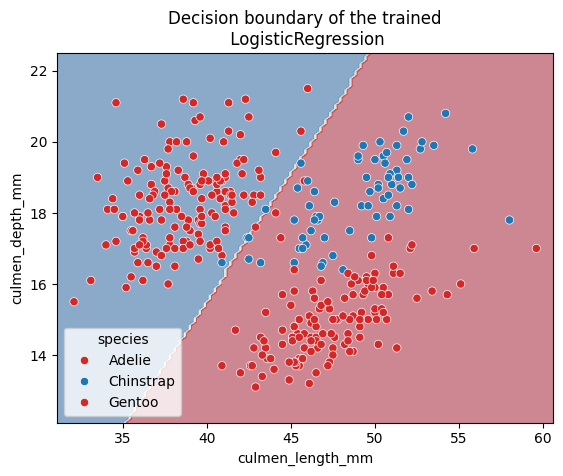

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import DecisionBoundaryDisplay

DecisionBoundaryDisplay.from_estimator(
    model,
    penguins[feature_names],
    response_method="predict",
    cmap="RdBu_r",
    alpha=0.5,
)
sns.scatterplot(
    data=penguins[[feature_names[0], feature_names[1], target_name]],
    x=feature_names[0],
    y=feature_names[1],
    hue=target_name,
    palette=["tab:red", "tab:blue"],
)
_ = plt.title("Decision boundary of the trained\n LogisticRegression")
plt.gcf().savefig("../assets/lab_logistic_decision_boundary.png", bbox_inches="tight", dpi=150)

Thus, we see that our decision function is represented by a straight line separating the 2 classes.

Similarly to the hard decision boundary shown above, one can set the `response_method` to `"predict_proba"` in the `DecisionBoundaryDisplay` to rather show the confidence on individual classifications. In such case the boundaries encode the estimated probablities by color. In particular, when using [matplotlib diverging colormaps](https://matplotlib.org/stable/users/explain/colors/colormaps.html#diverging) such as `"RdBu_r"`, the softer the color, the more unsure about which class to choose (the probability of 0.5 is mapped to white color).

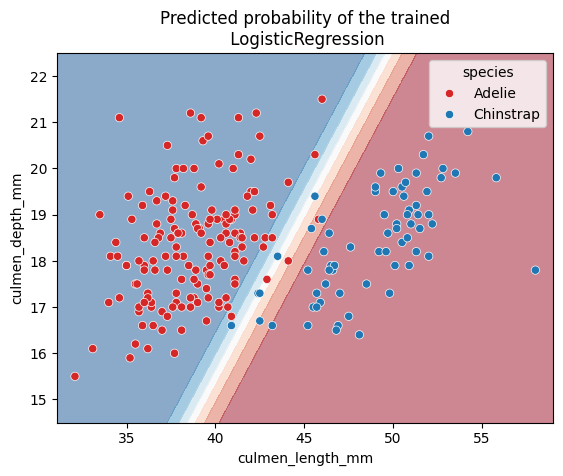

In [51]:
DecisionBoundaryDisplay.from_estimator(
    model,
    penguins[feature_names],
    response_method="predict_proba",
    cmap="RdBu_r",
    alpha=0.5,
)
sns.scatterplot(
    data=penguins[[feature_names[0], feature_names[1], target_name]],
    x=feature_names[0],
    y=feature_names[1],
    hue=target_name,
    palette=["tab:red", "tab:blue"],
)
_ = plt.title("Predicted probability of the trained\n LogisticRegression")
plt.gcf().savefig("../assets/lab_logistic_decision_boundary_proba.png", bbox_inches="tight", dpi=150)

For multi-class classification the logistic regression uses the [softmax function](https://en.wikipedia.org/wiki/Softmax_function) to make predictions. Giving more details on that scenario is beyond the scope of this course.

In any case, interested users are referred to the [scikit-learn user guide](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression) for a more mathematical description of the `predict_proba` method of the `LogisticRegression` and the respective normalization functions.